The imports

In [1]:
import pygsti
import pygsti.modelmembers as mm
import numpy as np
import sympy as sp
from main_functions_github import *
from pygsti.modelpacks import smq2Q_XYCNOT
from pygsti.baseobjs import basis
import matplotlib.pyplot as plt
import scipy.stats as stats

**Gate model definition**

We first need to define classes for the gates present in our gate set. Let us start with the single-qubit gates, which are parameterized under a coloured noise model.

In [2]:
#operator class for the single-qubit gate

class G(pygsti.modelmembers.operations.DenseOperator):

    def __init__(self, markov_approx, intensity_noise, pulse_duration, phase, representation, gate_indices, gate_index, init_values = None):
        #initialize with no noise
        super(G, self).__init__(np.identity(4,'d'), 'pp', "densitymx") 
        
        self.markov_approx = markov_approx
        self.intensity_noise = intensity_noise
        self.pulse_duration = pulse_duration
        self.phase = phase
        self.representation = representation
        self.gate_indices = gate_indices
        self.gate_index = gate_index

        if init_values is None:
            init_values = [0, 1e-8]  # Default small values
            if not self.markov_approx:
                init_values.extend([0, 0])
            if self.intensity_noise:
                init_values.append(0)

        self.from_vector(init_values)

    def _num_params(self):
        if self.intensity_noise:
            return 3 if self.markov_approx else 5
        else:
            return 2 if self.markov_approx else 4
        
    #return the number of parameters
    @property
    def num_params(self):
        return self._num_params()

    #return the labels of the parameters
    @property
    def parameter_labels(self):
        gate_index1, gate_index2 = self.gate_indices[0], self.gate_indices[1]

        return [f'{"(G" + str(gate_index1 + 1) + ")" if self.gate_index == 0 else "G" + str(gate_index1 + 1)}'
                f'{"(G" + str(gate_index2 + 1) + ")" if self.gate_index == 1 else "G" + str(gate_index2 + 1)} param{i+1}' 
                for i in range(self._num_params())]

    #parameter bounds
    @property
    def parameter_bounds(self): #\Gamma_1 > 0 to ensure complete positivity of the matrices

        bounds = [(0, np.inf), (-np.inf, np.inf)]
        bounds.extend([(-np.inf, np.inf)] * (self._num_params() - 2))

        if self._num_params() == 3 or self._num_params() == 5:
            bounds[len(bounds) - 1] = (0, np.inf)

        return bounds
    
    def to_vector(self):

        vector = [self.Gamma_1, self.Delta_1]
        if not self.markov_approx:
            vector.append(self.Gamma_2)
            vector.append(self.Delta_2)
        if self.intensity_noise:
            vector.append(self.DeltaGamma)
            
        return np.array(vector, 'd')
        
    def from_vector(self, v, close = False, dirty_value = True):

        #initialize from parameter vector v
        self.Gamma_1, self.Delta_1 = v[0], v[1]
        self.Gamma_2, self.Delta_2, self.DeltaGamma = 0, 0, 0

        if not self.markov_approx:
            self.Gamma_2, self.Delta_2 = v[2], v[3]
        if self.intensity_noise:
            self.DeltaGamma = v[2 if self.markov_approx else 4]

        # we build the gate in the phase noise model using the function `build_gate_ptm'
        self._ptr[:,:] = build_gate_ptm(np.array([self.Gamma_1, self.Delta_1,  self.Gamma_2,  self.Delta_2, self.DeltaGamma], 'd'),
                                    self.pulse_duration, self.markov_approx, self.intensity_noise, phase = self.phase)

        self.dirty = dirty_value  # mark that parameter vector may have changed

    # This should be included if gauge optimization is performed
    # def transform(self, S):
    # # Update self with inverse(S) * self * S (used in gauge optimization)
    #     return self

Now we define the functions and the class for the two-qubit light shift gate including frequency and thermal errors.

In [3]:
# We define the \phi trajectory function present in the displacement operator
def phi(F, omega_mode, omega_laser, t):

    deltaX = omega_mode - omega_laser
    return F * (1/deltaX) * (1 - np.exp(1j * deltaX * t))

def phi_with_non_resonant_terms(F, omega_mode, omega_laser, t):

    delta = omega_mode - omega_laser
    sum_frecs = omega_laser + omega_mode

    return F * ((1/delta) * (1 - np.exp(1j * delta * t)) + (1/sum_frecs) * (1 - np.exp( - 1j * sum_frecs * t)))


# spin-spin coupling J_{i,j}
def spin_spin_coupling(F, omega_laser, omega_modes, t):

    deltas = omega_modes - omega_laser
    sum_frecs = omega_laser + omega_modes

    J_values = 2 * np.real((F[0, :] * F[1, :])) * ( (1/deltas + 1/sum_frecs) * (- t) + 1/(deltas**2) * (- np.sin(deltas*t)) + 1/(sum_frecs**2) * (- np.sin(sum_frecs*t)) + \
        + 1 / (deltas*sum_frecs) * (sum_frecs + deltas)/(sum_frecs - deltas) * (- np.sin(sum_frecs*t)) + 1 / (deltas*sum_frecs) * (- np.sin(sum_frecs*t) - np.sin(deltas*t)))
    
    J = np.sum(J_values)

    return J

# Dephasing channel 

Gamma_symbol = sp.Symbol('Gamma_symbol', real=True)
p_deph = sp.Symbol('p_deph', real=True)

DephasingEq = sp.Matrix([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, Gamma_symbol, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, Gamma_symbol, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 4 * Gamma_symbol, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, Gamma_symbol, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, Gamma_symbol, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, Gamma_symbol, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, Gamma_symbol, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4 * Gamma_symbol, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, Gamma_symbol, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, Gamma_symbol, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

DephasingChannel = sp.exp(DephasingEq)

J = sp.Symbol('J', real=True)
omega_0, t = sp.symbols('omega_0, t', real=True, positive = True)

# ZZ interaction
# Uniray operator
ZZ_unitary = sp.Matrix(sp.cos(J) * np.kron(pauli_i, pauli_i) - 1j * sp.sin(J) * np.kron(pauli_z, pauli_z))

# Superoperator in natural representation
ZZ_channel = np.kron(ZZ_unitary, ZZ_unitary.conjugate())

#Z rotation
# Uniray operator
Z_unitary = sp.Matrix(np.kron(sp.cos(omega_0 * t) * pauli_i - 1j * sp.sin(omega_0 * t) * pauli_z, sp.cos(omega_0 * t) * pauli_i - 1j * sp.sin(omega_0 * t) * pauli_z))

# Superoperator in natural representation
Z_channel = np.kron(Z_unitary, Z_unitary.conjugate())

# variables
phi_1 = sp.Symbol('phi_1', real=True)
p_th = sp.Symbol('p_th', real=True)

# Spin-dependent displacement (superoperator)
SDD_channel = sp.Matrix([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, sp.exp(phi_1), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, sp.exp(phi_1), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, sp.exp(phi_1), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, sp.exp(4 * phi_1), 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, sp.exp(phi_1), 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, sp.exp(phi_1), 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, sp.exp(4 * phi_1), 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, sp.exp(phi_1), 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, sp.exp(phi_1), 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, sp.exp(phi_1), 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])


# complete channel
complete_channel = sp.simplify(sp.Matrix(Z_channel@SDD_channel@ZZ_channel@DephasingChannel))

# we change of basis to the pauli basis to obtain the PTM representation
from_basis = basis.BuiltinBasis('std', 16)

basis_change_matrix = from_basis.create_transform_matrix('pp')
inv_basis_change_matrix = np.linalg.inv(basis_change_matrix)

# We compute the product of channels instead of the basis-transformed complete channel for simplification reasons 
channel_pp = sp.Matrix(basis_change_matrix@Z_channel@inv_basis_change_matrix) @\
             sp.Matrix(basis_change_matrix@ZZ_channel@inv_basis_change_matrix) @\
             sp.Matrix(basis_change_matrix@SDD_channel@inv_basis_change_matrix) @\
             sp.Matrix(basis_change_matrix@DephasingChannel@inv_basis_change_matrix)

# We redefine some variables
channel_pp = sp.Matrix(sp.simplify(channel_pp)).subs(sp.exp(Gamma_symbol), p_deph).subs(sp.exp(phi_1), p_th)


# we make a numpy version of the channel inside a function to define our gate model
channel_func = sp.lambdify((p_deph, p_th, J, omega_0, t), channel_pp, 'numpy')

def channel_complete_two_qubits(p_deph, p_th, J, omega_0, t):
    return np.array(channel_func(p_deph, p_th, J, omega_0, t), dtype = np.float64)

channel_pp

Matrix([
[1.0,                                                                  0,                                                                  0,   0,                                                                  0,                                                                                                0,                                                                                               0,                                                                  0,                                                                  0,                                                                                               0,                                                                                                0,                                                                  0,   0,                                                                  0,                                                                  0,   0],
[  0,  0.5*p_deph*p_th*(cos(2*J - 2

Now we can define the LS class

In [4]:
class LS(pygsti.modelmembers.operations.DenseOperator):

    def __init__(self, omega_0, omega_laser, omega_modes, F, phi_values_experiment, t, init_value = None):
        #initialize with no noise
        super(LS, self).__init__(np.identity(16,'d'), 'pp', "densitymx")

        self.omega_0 = omega_0
        self.omega_laser = omega_laser
        self.omega_modes = omega_modes
        self.phi_values_experiment = phi_values_experiment
        self.F = F
        self.t = t

        if init_value is None:
            init_value = [1, 1]

        self.from_vector(init_value)

    def _num_params(self):
        return 2
    
    #return the number of parameters
    @property
    def num_params(self):
        return self._num_params()

    #parameter bounds
    @property
    def parameter_bounds(self): 

        bounds = [(0, 1.01), (0, 1.01)] # To avoid bias in the predicted scalings, we let the bounds slightly exceed the physical limits

        return bounds
    
    def to_vector(self):

        vector = [self.p_depth_parameter, self.p_thermal_parameter] 
            
        return np.array(vector, 'd')
        
    def from_vector(self, v, close = False, dirty_value = True):

            #initialize from parameter vector v
            self.p_depth_parameter = v[0]
            self.p_thermal_parameter = v[1]

            J = spin_spin_coupling(self.F, self.omega_laser, self.omega_modes, self.t)

            self._ptr[:,:] = channel_complete_two_qubits(self.p_depth_parameter, self.p_thermal_parameter, J, self.omega_0, self.t)

            self.dirty = dirty_value  # mark that parameter vector may have changed

We define a theoretical model for GST, which consists on a set of single-qubit gates plus the LS gate.

In [5]:
num_qubits = 2

# For single-qubit gates, we consider no intensity noise and the markovian approximation. This can be modified at will.
markov_approx = True
intensity_noise = False

# Empty models
mdl_SPAM = pygsti.models.ExplicitOpModel(0,'pp')
mdl_complete = pygsti.models.ExplicitOpModel(range(num_qubits),'pp')
mdl_complete_fully_general = pygsti.models.ExplicitOpModel(range(num_qubits),'pp')

# Single-qubit labels
myGates = ['G1', 'G2', 'G3', 'G4', 'G5']

# Phase and pulse duration parameters for the gates
gateSetParams = {'G1': [np.pi, 0], 
                 'G2': [np.pi / 2, 0],
                 'G3': [np.pi / 2, np.pi / 2],
                 'G4': [np.pi / 2, np.pi],
                 'G5': [np.pi / 2, 3 * np.pi / 2]}

# We call the class and make serialized versions of all posible gate combinations
for idx1, i in enumerate(myGates):
    for idx2, j in enumerate(myGates):
            
            Op1 = G(markov_approx, intensity_noise, *gateSetParams[i], 'PTM', [idx1, idx2], 0)
            Op2 = G(markov_approx, intensity_noise, *gateSetParams[j], 'PTM', [idx1, idx2], 1)

            mdl_complete.operations[(i + j, 0, 1)] = mm.operations.ComposedOp(
                                        (mm.operations.EmbeddedOp([0, 1], [0], Op1),
                                        mm.operations.EmbeddedOp([0, 1], [1], Op2))
                                        )

# Some physical paremeters

n_value_active, n_value_spectator = 5, 5 # phonons in each mode
n_values = [n_value_active, n_value_spectator]

omega_0 = (2 * np.pi * 10.5) * 1e6
omega_modes = 1e6 * (2 * pi) * np.array([1.49, 2.57]) # Axial phonon mode frequencies
omega_laser = omega_modes[0] - 2 * np.pi / (95.3295 * 1e-6)
omega_rabi = 2 * np.pi * 50 * 1e3

t_gate = 2 * np.pi / (omega_modes[0] - omega_laser)  # We set the time to close the COM mode trajectory

F = 23397.9839798398 * 1j/np.sqrt(2) * np.array([[1, 1], 
                                          [1, -1]])

# We compute the values of the trajectory phi functions
phi_values_experiment = np.zeros((np.size(F, 0), np.size(F, 1)), dtype = complex)

for i in range(np.size(F, 0)):
    for m in range(np.size(F, 1)):
        phi_values_experiment[i, m] = phi_with_non_resonant_terms(F[i, m], omega_modes[m], omega_laser, t_gate)


# We add the LS gate to the model
mdl_complete[('Gls', 0, 1)] = LS(omega_0, omega_laser, omega_modes, F, phi_values_experiment, t_gate)

# We define SPAM using tensor product of single-qubit components
mdl_SPAM[('rho0_1')] = mm.states.TPState( np.array([ 1/sqrt(2), 0, 0, 1/sqrt(2) ], 'd'), 
                                    evotype = 'densitymx')

mdl_SPAM[('rho0_2')] = mm.states.TPState( np.array([ 1/sqrt(2), 0, 0, 1/sqrt(2) ], 'd'), 
                                    evotype = 'densitymx')

mdl_SPAM[('Mdefault_1')] = mm.povms.TPPOVM(
                        {'0': [ 1/sqrt(2), 0, 0, 1/sqrt(2) ],   
                        '1': [ 1/sqrt(2), 0, 0, -1/sqrt(2) ] },
                        evotype = 'densitymx') 

mdl_SPAM[('Mdefault_2')] = mm.povms.TPPOVM(
                        {'0': [ 1/sqrt(2), 0, 0, 1/sqrt(2) ],   
                        '1': [ 1/sqrt(2), 0, 0, -1/sqrt(2) ] },
                        evotype = 'densitymx') 

mdl_complete[('rho0', 0, 1)] = mm.states.TensorProductState([mdl_SPAM[('rho0_1')], mdl_SPAM[('rho0_2')]], [0, 1])
mdl_complete[('Mdefault', 0, 1)] = mm.povms.TensorProductPOVM([mdl_SPAM[('Mdefault_1')], mdl_SPAM[('Mdefault_2')]], 
                                                        'densitymx')

print(mdl_complete.num_params)

116


In [6]:
# Let us check that the spin-spin coupling is apprix. pi/4.as_integer_ratio

J_experimental = spin_spin_coupling(F, omega_laser, omega_modes, t_gate)

print(J_experimental)
print(np.pi / 4)

0.7854008900816303
0.7853981633974483


Now we have to collect some parameters. We know that, for single qubit operations under this noise model, gates with same pulse duration share parameters, irrespective of the phases. Also, because we have defined serialized versions of all posible single-qubit gates, we need to collect parameters for those sets of two-qubit serialized gates with the same single-qubit gate in one of the two qubits, as we do not consider crosstalk for this example. We do it as follows

In [7]:
params_labels = mdl_complete.parameter_labels

# We first collect parameters from the non-crosstalk model
for i in myGates:
    collectable_params1, collectable_params2, collectable_params3, collectable_params4 = [], [], [], []
    for j in myGates:

        collectable_params1.append([element for element in params_labels if element[1] == mdl_complete.operations[(i + j, 0, 1)].parameter_labels[0]][0]) 
        collectable_params2.append([element for element in params_labels if element[1] == mdl_complete.operations[(i + j, 0, 1)].parameter_labels[1]][0]) 
        collectable_params3.append([element for element in params_labels if element[1] == mdl_complete.operations[(j + i, 0, 1)].parameter_labels[2]][0]) 
        collectable_params4.append([element for element in params_labels if element[1] == mdl_complete.operations[(j + i, 0, 1)].parameter_labels[3]][0]) 

    mdl_complete.collect_parameters(collectable_params1) # Name of the new parameter is by default set to the first collected parameter
    mdl_complete.collect_parameters(collectable_params2)
    mdl_complete.collect_parameters(collectable_params3)
    mdl_complete.collect_parameters(collectable_params4)

# We also collect parameters which are equal because of the physical modelling
collectable_params1, collectable_params2, collectable_params3, collectable_params4 = [], [], [], []
for i in myGates[1:]: # Last 4 gates share parameters bc have the same pulse duration CAREFUL WITH THIS
    collectable_params1.append([element for element in params_labels if element[1] == mdl_complete.operations[(i + 'G1', 0, 1)].parameter_labels[0]][0])
    collectable_params2.append([element for element in params_labels if element[1] == mdl_complete.operations[(i + 'G1', 0, 1)].parameter_labels[1]][0]) 
    collectable_params3.append([element for element in params_labels if element[1] == mdl_complete.operations[('G1' + i, 0, 1)].parameter_labels[2]][0]) 
    collectable_params4.append([element for element in params_labels if element[1] == mdl_complete.operations[('G1' + i, 0, 1)].parameter_labels[3]][0]) 

mdl_complete.collect_parameters(collectable_params1)
mdl_complete.collect_parameters(collectable_params2)
mdl_complete.collect_parameters(collectable_params3)
mdl_complete.collect_parameters(collectable_params4)

# We again print the number of parameteres, which should be 24
print(mdl_complete.num_params)

24


/opt/miniconda3/envs/coloured_GST/lib/python3.13/site-packages/pygsti/models/model.py:1006: UserWarning: Internal Model attributes are being rebuilt. This is likely because a modelmember has been either added or removed. If you have manually set parameter bounds values at the Model level (not the model member level), for example using the `set_parameter_bounds` method, these values will be overwritten by the parameter bounds found in each of the modelmembers.
  _warnings.warn(msg)


**Model for simulations**

Now that the theoretical model is finished, we define a experimental model to simulate results.

In [8]:
mdl_experimental = pygsti.models.ExplicitOpModel(range(num_qubits),'pp')

# Some noise parameters for the OU-noise simulations
c, tau = 2 * 1e9, 5 * 1e-4

# For this noise model, Gamma noise parameter can be computed exaclty.
def Gamma(c, tau, t):
    return - c * tau ** 2 / 2 * (t + tau * (np.exp( -t / tau) - 1))

# physical parameters
J_experimental = spin_spin_coupling(F, omega_laser, omega_modes, t_gate)
phi_1_experimental = - (np.abs(2 * phi_values_experiment[1, 1]) ** 2) * (1/2 + n_value_spectator)
Gamma_value = Gamma(c, tau, t_gate)

# Experimental LS gate
mdl_experimental[('Gls', 0, 1)] = channel_complete_two_qubits(np.exp(Gamma_value), np.exp(phi_1_experimental), J_experimental, omega_0, t_gate)

# For single qubit gates there is not exact closed form for the numerical parameters. Therefore, we need to 
# compute an average over stochastic trajectories

# Number of stochastic trajectories
Mnoise = 1e3 #Only for testing purpouses. To have an acceptable accuracy set at least Mnoise = 1e4

# Experimental single-qubit gates
mdl_single_qubit = pygsti.models.ExplicitOpModel([0],'pp')
           
for idx, gate in enumerate(myGates):
    mdl_single_qubit[(gate)] = chi2ptm(stochastic_matrices([gateSetParams[gate][1]], Mnoise, gateSetParams[gate][0], intensity_noise, [c], [tau], omega_rabi)[0])


for idx1, i in enumerate(myGates):
    for idx2, j in enumerate(myGates):
            
            Op1 = mdl_single_qubit[(i)]
            Op2 = mdl_single_qubit[(j)]

            mdl_experimental.operations[(i + j, 0, 1)] = mm.operations.ComposedOp(
                                        (mm.operations.EmbeddedOp([0, 1], [0], Op1),
                                        mm.operations.EmbeddedOp([0, 1], [1], Op2)))

# SPAM
mdl_experimental[('rho0', 0, 1)] = smq2Q_XYCNOT.target_model().preps[('rho0')]
mdl_experimental[('Mdefault', 0, 1)] = smq2Q_XYCNOT.target_model().povms['Mdefault']

/opt/miniconda3/envs/coloured_GST/lib/python3.13/site-packages/pygsti/modelmembers/operations/embeddedop.py:94: ComplexWarning: Casting complex values to real discards the imaginary part
  self._rep.base[:, :] = self.to_dense(on_space='minimal')
/opt/miniconda3/envs/coloured_GST/lib/python3.13/site-packages/pygsti/modelmembers/operations/composedop.py:121: ComplexWarning: Casting complex values to real discards the imaginary part
  self._rep.base[:, :] = mx


**Circuit selection**

We chose the circuits to employ for the GST protocol. From our precious work, we already know single-qubit gate circuits.

In [9]:
max_lenght_considered = [2**10]

single_qubit_circuits = [pygsti.circuits.Circuit([('G3G3', 0, 1)]) + pygsti.circuits.Circuit([('G1G1', 0, 1)]) ** max_lenght_considered[0] + pygsti.circuits.Circuit([('G3G3', 0, 1)]),
                           pygsti.circuits.Circuit([('G4G4', 0, 1)]) + pygsti.circuits.Circuit([('G1G1', 0, 1)]) ** max_lenght_considered[0] + pygsti.circuits.Circuit([('G1G1', 0, 1)]),
                           pygsti.circuits.Circuit([('G3G3', 0, 1)]) + pygsti.circuits.Circuit([('G2G2', 0, 1)]) ** max_lenght_considered[0] + pygsti.circuits.Circuit([('G3G3', 0, 1)]),
                           pygsti.circuits.Circuit([('G1G1', 0, 1)]) + pygsti.circuits.Circuit([('G2G2', 0, 1)]) ** max_lenght_considered[0] + pygsti.circuits.Circuit([('G2G2', 0, 1)])]

For the entangling gate, we know that the LS gate is a valid germ to amplify errors. Therefore, we only need to select the best fiducial pairs. To do so, we star by computing the outputs circuits consisting of all possible fiducial pairs sandwiching the LS gate when gates are unitary.

In [10]:
params_labels = mdl_complete.parameter_labels
number_of_spam_elements = len(mdl_complete[('rho0', 0, 1)].to_vector()) + len(mdl_complete[('Mdefault', 0, 1)].to_vector()) - 1

gates_list = [[i] for i in mdl_complete.operations.keys()]

# State preparation
prep_fiducials = gates_list.copy()
prep_fiducials = pygsti.circuits.to_circuits(prep_fiducials, line_labels=[0,1])

# Measurement
meas_fiducials = gates_list.copy()
meas_fiducials = pygsti.circuits.to_circuits(meas_fiducials, line_labels=[0,1])

# List of experiments from all sandwiches
listOfExperiments_complete = pygsti.circuits.gstcircuits.create_lsgst_circuits(
            mdl_complete, prep_fiducials, meas_fiducials, pygsti.circuits.to_circuits([[('Gls',0,1)]]), max_lenght_considered, include_lgst = False)

# Ideal data    
data_unperturbed = pygsti.data.simulate_data(mdl_complete, listOfExperiments_complete, num_samples = 1,
                                         sample_error = 'none')

Now, we slightly deviate the LS gate from the ideal version and compute the same circuits again. We will chose those fiducial pairs which exhibit a large variation of the experimental frequencies.

In [11]:
# small parameter deviation
epsilon = 1e-3
selected_circuits = []

# Include the single-qubit circuits in the list of selected circuits.
selected_circuits = single_qubit_circuits

# We will store circuits with similar frequencies.
selected_circuits_with_redundancies = selected_circuits.copy()

# We count how many more circuits we need to select.
ls_pairs = int(mdl_complete.num_params / 2 - len(single_qubit_circuits))

for i in range(ls_pairs):
    
    # We perturb the first LS parameter
    index = len(params_labels) - 2

    if i%2 == 0: # We perturb the second parameter LS instead half of the times
        index += 1

    # We define the variated parameters and the new deviated model
    params = mdl_complete.to_vector()
    new_params = np.copy(mdl_complete.to_vector())
    new_params[index] = new_params[index] + epsilon
    mdl_complete.from_vector(new_params)

    # List of experiments
    listOfExperiments = pygsti.circuits.gstcircuits.create_lsgst_circuits(
                gates_list, prep_fiducials, meas_fiducials, pygsti.circuits.to_circuits([[('Gls',0,1)]]), max_lenght_considered, include_lgst = False)

    # Use only the circuits which have not been used already 
    listOfExperiments = [x for x in listOfExperiments if x not in selected_circuits_with_redundancies]

    # Data with perturbed model
    data_perturbed = pygsti.data.simulate_data(mdl_complete, listOfExperiments, num_samples = 1,
                                            sample_error = 'none')
    
    # We restore the original model
    mdl_complete.from_vector(params)
    
    # We compute the frequency diference between perturbed and unperturbed data.
    data_dif = {}
    for circ in listOfExperiments:
        data_dif[circ] = np.abs((data_perturbed[circ][('00',)] - data_unperturbed[circ][('00',)])) +\
                         np.abs((data_perturbed[circ][('01',)] - data_unperturbed[circ][('01',)])) +\
                         np.abs((data_perturbed[circ][('10',)] - data_unperturbed[circ][('10',)]))
    
    # We select the circuit with the maximum frequency difference
    selected_circuits.append(max(data_dif, key = data_dif.get))

    # It might be the case that we select a diferent circuit with the same theoreitical probaility as other already selected.
    # Therefore, we ignore circuits whose frequencies are similar to already chosen circuits.
    max_value = max(data_dif.values())
    maxpositions = [circ for circ, value in data_dif.items() if abs(value - max_value) <= 1e-3]
    selected_circuits_with_redundancies += maxpositions

# We write the circuits as a fidPairs dictionary
germs = pygsti.circuits.to_circuits(gates_list, line_labels=[0,1])
fidPairs = {}
for i, germ in enumerate(germs):
    if germ not in fidPairs:
        fidPairs[germ] = []
    for j, prep in enumerate(prep_fiducials):
        for k, meas in enumerate(meas_fiducials):
            circuit = prep + germ ** max_lenght_considered[0] + meas
            if circuit in single_qubit_circuits:
                fidPairs[germ].append((j, k))

In [12]:
# If we do not wish to do fiducial pair reduction, we can select all possible fiducial pairs like this

# ls_fp = []
# for i in range(len(prep_fiducials)):
#     for j in range(len(meas_fiducials)):
#         ls_fp.append((i,j))

# fidPairs[pygsti.circuits.Circuit([('Gls',0,1)])] = ls_fp

**Run GST**

We can finally run GST with our theoretical model and the experimental model, as well as the selected circuits. We will get results similar to those of FIG.2 in our paper.

First, we run GST with the usual structure, including logarithmically-spaced depths in the same optimization rountine.

In [13]:
shots = 1e4 # Number of times each circuit is sampled

# We iterate over many GST optimzations to get statistics.
iterations = 15

# list of max lengths for long-sequence circutis
maxLengths = [2**i for i in range(12)]

# Array to store results
results_vs_p = np.empty([len(maxLengths), iterations])

#######BORRAR
results_vs_p2 = np.empty([len(maxLengths), iterations])
results_vs_p3 = np.empty([len(maxLengths), iterations])

#some custom GST options
my_adv_options = {'tolerance': 1e-4,'starting_point': 'target', 'max_iterations': 1000,'min_prob_clip': 1 / shots}

listOfExperiments = pygsti.circuits.gstcircuits.create_lsgst_circuits(
    mdl_experimental, prep_fiducials, meas_fiducials, germs, maxLengths, include_lgst = False, fid_pairs = fidPairs)

for iter in range(iterations): 
    print(iter)

    # Noisy data
    data = pygsti.data.simulate_data(mdl_experimental, listOfExperiments, num_samples = shots,
                                        sample_error = 'multinomial')
    #run lsGST
    results = pygsti.run_long_sequence_gst(data, mdl_complete, prep_fiducials, meas_fiducials,
                                            germs, maxLengths, gauge_opt_params = False, advanced_options = my_adv_options, verbosity = 1)


    get_results = results.estimates['GateSetTomography']
    
    # We get the distance to the experimental model. No gauge optimization is needed.
    for i in range(len(get_results.models) - 4):
            
        mdl_estimate = results.estimates['GateSetTomography'].models[f'iteration {i} estimate']

        # SPAM parameters arenot amplified in long-sequence GST, and therefore not used to compute scalings.
        results_vs_p[i, iter] = mdl_estimate.jtracedist(mdl_experimental, include_spam = False) # To be fully consistent, use diamonddinst instead of jtracedist (it takes longer)
        results_vs_p2[i, iter] = mdl_estimate[('G1G1', 0, 1)].jtracedist(mdl_experimental[('G1G1', 0, 1)])
        results_vs_p3[i, iter] = mdl_estimate[('Gls', 0, 1)].jtracedist(mdl_experimental[('Gls', 0, 1)])
        

0


/opt/miniconda3/envs/coloured_GST/lib/python3.13/site-packages/pygsti/modelmembers/operations/composedop.py:342: ComplexWarning: Casting complex values to real discards the imaginary part
  v[factorgate_local_inds] = operation.to_vector()


--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  144 circuits ---
1
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  144 circuits ---
2
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  144 circuits ---
3
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  144 circuits ---
4
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  144 circuits ---
5
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  144 circuits ---
6
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  144 circuits ---
7
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  144 circuits ---
8
--- Circ

We plot the results vs depth. We recover the -1 slope tendency with a plateau in the region near p=10^3, indicating that noise dominates the dynamics and no further information can be obtained by repeating the germs. A slight shift is apreciated with respect to the figure in the paper because here we are employing the trace distance instead of the diamond one.

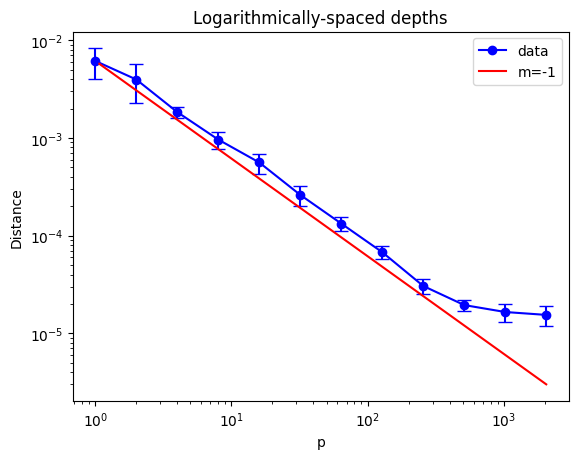

In [14]:
#we average ethe results over the iterations
distances = results_vs_p.mean(axis = 1)

means = np.mean(results_vs_p, axis=1)
sem = stats.sem(results_vs_p, axis=1) 
conf_interval = stats.t.ppf(0.975, df = results_vs_p.shape[1]-1) * sem

# Creating the log-log plot
plt.loglog(maxLengths, distances, marker='o', linestyle='-', color='b', label = 'data')
plt.errorbar(maxLengths, means, yerr = conf_interval, fmt='.', capsize=5, color='b', markersize=8)

# m=-1 expected slope
plt.loglog(maxLengths, distances[0]/np.array(maxLengths), color='red', label = 'm=-1')

# Labels and title
plt.xlabel('p')
plt.ylabel('Distance')
plt.title('Logarithmically-spaced depths')
plt.legend()

plt.show()

We can now obtain the same results but including only the last depth in the sucessive optimizations, not including prior shorter cirucuits.

In [17]:
shots = 1e4 # Number of times each circuit is sampled

# We iterate over many GST optimzations to get statistics.
iterations = 15

# list of max lengths for long-sequence circutis
maxLengths = [2**i for i in range(12)]

results_vs_p = np.empty([len(maxLengths), iterations])

#some custom GST options
my_adv_options = {'tolerance': 1e-4,'starting_point': 'target', 'max_iterations': 1000,'min_prob_clip': 1 / shots}

#######BORRAR
results_vs_p2 = np.empty([len(maxLengths), iterations])
results_vs_p3 = np.empty([len(maxLengths), iterations])

for iter in range(iterations): 
    print(iter)

    for i, maxDepth in enumerate(maxLengths):

        # the list of experiments to execute with last depth only
        listOfExperiments = pygsti.circuits.gstcircuits.create_lsgst_circuits(
            mdl_experimental, prep_fiducials, meas_fiducials, germs, [maxDepth], include_lgst = False, fid_pairs = fidPairs) #should include fidPairs when needed # maxLengths[0:i+1]

        #simulate the data
        data = pygsti.data.simulate_data(mdl_experimental, listOfExperiments, num_samples = shots,
                                            sample_error = 'multinomial')

        #run lsGST
        results = pygsti.run_long_sequence_gst(data, mdl_complete, prep_fiducials, meas_fiducials,
                                            germs, [maxDepth], gauge_opt_params = False, advanced_options = my_adv_options, verbosity = 1)# maxLengths[0:i+1]

        get_results = results.estimates['GateSetTomography']

        mdl_estimate = results.estimates['GateSetTomography'].models['final iteration estimate']

        # Store the results
        results_vs_p[i, iter] = mdl_estimate.jtracedist(mdl_experimental, include_spam = False)
        results_vs_p2[i, iter] = mdl_estimate[('Gls', 0, 1)].jtracedist(mdl_experimental[('Gls', 0, 1)])
        results_vs_p3[i, iter] = mdl_estimate[('G1G1', 0, 1)].jtracedist(mdl_experimental[('G1G1', 0, 1)])
        

0
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- I

Plot of the results. As expected, the noise-dominated region now shows a degradation of the results because of the absence of shorter circuits, but the m=-1 tendency is also achieved.

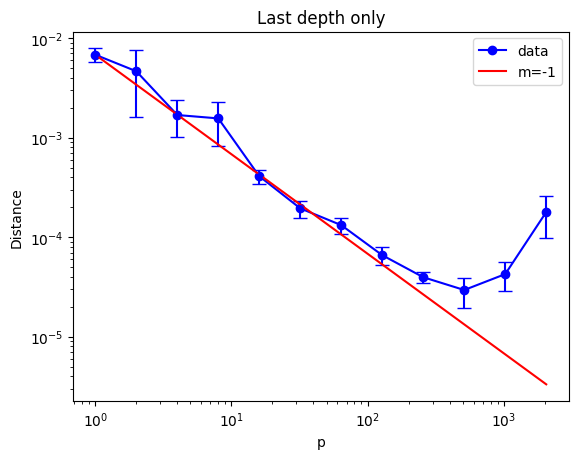

In [18]:
#we average ethe results over the iterations
distances = results_vs_p.mean(axis = 1)

means = np.mean(results_vs_p, axis=1)
sem = stats.sem(results_vs_p, axis=1) 
conf_interval = stats.t.ppf(0.975, df = results_vs_p.shape[1]-1) * sem

# Creating the log-log plot
plt.loglog(maxLengths, distances, marker='o', linestyle='-', color='b', label = 'data')
plt.errorbar(maxLengths, means, yerr = conf_interval, fmt='.', capsize=5, color='b', markersize=8)

# m=-1 expected slope
plt.loglog(maxLengths, distances[0]/np.array(maxLengths), color='red', label = 'm=-1')

# Labels and title
plt.xlabel('p')
plt.ylabel('Distance')
plt.title('Last depth only')
plt.legend()

plt.show()